@author: James Talwar

# Validation Set Analysis: Autoimmune Alleles and Age of Diagnosis

**About:** This notebook provides the code needed to generate Figure 1E and Supplementary Figure 5 from the paper [*Autoimmune Alleles at the Major Histocompatibility Locus Modify Melanoma Susceptibility*](https://www.biorxiv.org/content/10.1101/2021.08.12.456166v1.full). These analyses evaluated MHC-I autoimmune allele status in the validation set (N=586).

## 1. Import Packages and Load in Preprocessed Data

In [1]:
import pandas as pd
from collections import defaultdict
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.stats import mannwhitneyu
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [2]:
validationSetStatus = pd.read_csv("../GenotypeData/Validation_All.tsv", sep = "\t", index_col = 0) #contains AI/Non-AI allele status, sex, and age information for the validation set
print("Number of validation cohort individuals: {}".format(validationSetStatus.shape[0]))

Number of validation cohort individuals: 586


## 2. Generate Figures

### a. Figure 1E



Statistic = 35791.000, p= 0.04351306
Different distribution (reject H0)


Text(0.5, 0, 'Has Autoimmune Allele')

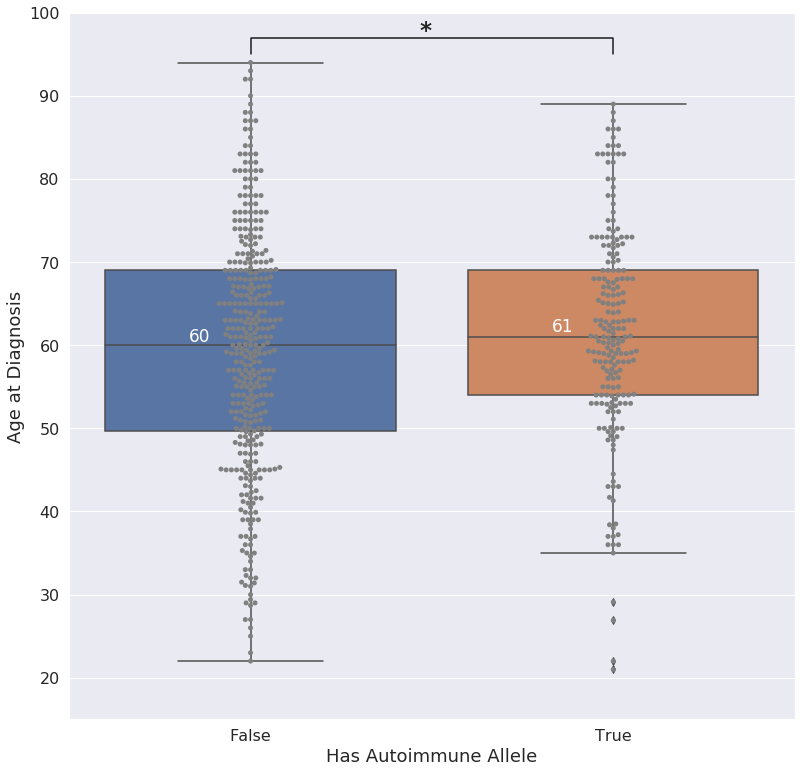

In [3]:
sns.set(font_scale = 1.1)
plt.figure(figsize=(13,13))

stat,p = mannwhitneyu(list(pd.to_numeric(validationSetStatus[validationSetStatus["HasProtection"]]["Age at Diagnosis"])), list(pd.to_numeric(validationSetStatus[validationSetStatus["HasProtection"]==False]["Age at Diagnosis"])))
print("\n")
print('Statistic = %.3f, p= %.8f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Same distribution (fail to reject H0)')
else:
    print('Different distribution (reject H0)')

sns.boxplot(data = validationSetStatus, x = 'HasProtection', y = pd.to_numeric(validationSetStatus['Age at Diagnosis']))
sns.swarmplot(data = validationSetStatus, x = 'HasProtection', y = pd.to_numeric(validationSetStatus['Age at Diagnosis']), color = 'grey')
plt.ylim(17, 103)

plt.xlabel("Has Autoimmune Allele", fontsize = 15)
plt.ylabel("Age at Diagnosis", fontsize = 15)

plt.text(-.17, 60.5, str(int(np.median(validationSetStatus[(validationSetStatus["HasProtection"] == False)]["Age at Diagnosis"]))), color = "white", fontsize = 17)
plt.text(0.83, 61.7, str(int(np.median(validationSetStatus[validationSetStatus["HasProtection"]]["Age at Diagnosis"]))), color = "white", fontsize = 17)
plt.plot([0,0,1,1], [95, 97, 97, 95], lw = 1.5, c = 'k')
plt.text(0.465, 97, "*", fontsize = 23, fontweight = "bold")
plt.ylim(15,100)

plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.ylabel("Age at Diagnosis", fontsize = 18)
plt.xlabel("Has Autoimmune Allele", fontsize = 18)

### b. Supplementary Figure 5a

In [4]:
validationPlottingVisualization = validationSetStatus.copy()
validationPlottingVisualization["Age at Diagnosis"] = validationPlottingVisualization["Age at Diagnosis"].apply(np.round)



Statistic = 37193.500, p= 0.00344142
Different distribution (reject H0)


(array([ 10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100., 110.]),
 <a list of 11 Text yticklabel objects>)

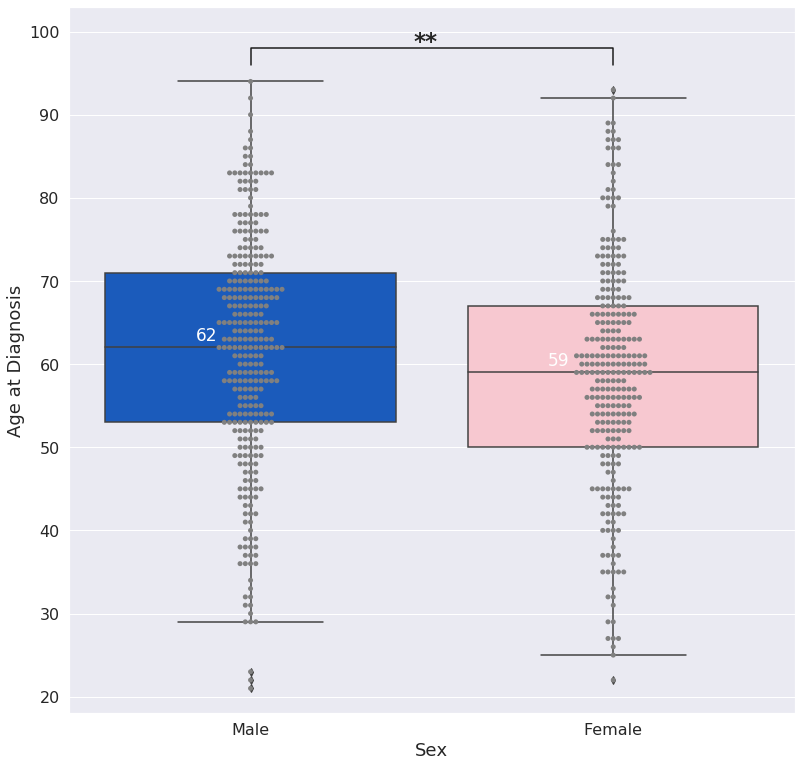

In [5]:
skittlesTasteTheRainbow = {"M":'#0056D6' , "F":"#FFC0CB"} #palette for color by sex 
stat,p = mannwhitneyu(list(pd.to_numeric(validationPlottingVisualization[validationPlottingVisualization["Sex"] == "M"]["Age at Diagnosis"])), list(pd.to_numeric(validationPlottingVisualization[validationPlottingVisualization["Sex"]=="F"]["Age at Diagnosis"])))
print("\n")
print('Statistic = %.3f, p= %.8f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Same distribution (fail to reject H0)')
else:
    print('Different distribution (reject H0)')

plt.figure(figsize=(13,13))
sns.boxplot(data = validationPlottingVisualization, x = "Sex", y="Age at Diagnosis", palette = skittlesTasteTheRainbow)
sns.swarmplot(data = validationPlottingVisualization, x = "Sex", y="Age at Diagnosis", dodge= True, color = "grey")

plt.xlabel("Sex", fontsize = 18)
plt.ylabel("Age at Diagnosis", fontsize = 18)
plt.xticks([0, 1], ["Male", "Female"])
plt.yticks(fontsize=14)
plt.ylim(18, 103)

plt.text(-.15, 62.9, str(int(np.median(validationPlottingVisualization[(validationPlottingVisualization["Sex"] == "M")]["Age at Diagnosis"]))), color = "white", fontsize=17)
plt.text(.82, 59.9, str(int(np.median(validationPlottingVisualization[validationPlottingVisualization["Sex"] == "F"]["Age at Diagnosis"]))), color = "white", fontsize = 17)
plt.plot([0,0,1,1], [96, 98, 98, 96], lw = 1.5, c = 'k')
plt.text(0.45, 98, "**", fontsize = 23, fontweight = "bold")

plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

### c. Supplementary Figure 5b

Running mann-whitney for AI alleles in FEMALES...: 


Statistic = 8280.000, p= 0.236


Running mann-whitney for AI alleles in MALES...: 


Statistic = 9573.000, p= 0.055


Text(1.07, 59.9, '59')

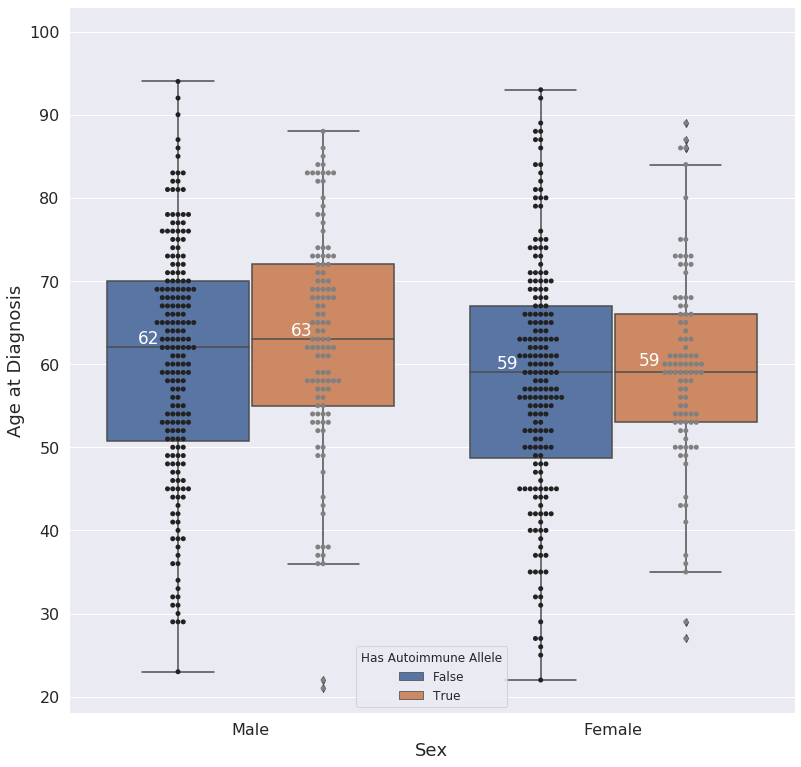

In [6]:
print("Running mann-whitney for AI alleles in FEMALES...: ")

stat,pFemale = mannwhitneyu(validationPlottingVisualization[(validationPlottingVisualization["Sex"] == "F")&(validationPlottingVisualization["HasProtection"])]["Age at Diagnosis"], validationPlottingVisualization[(validationPlottingVisualization["Sex"] == "F")&(validationPlottingVisualization["HasProtection"] == False)]["Age at Diagnosis"])
print("\n")
print('Statistic = %.3f, p= %.3f' % (stat, pFemale))

print("\n")

print("Running mann-whitney for AI alleles in MALES...: ")

stat,pMale = mannwhitneyu(validationPlottingVisualization[(validationPlottingVisualization["Sex"] == "M")&(validationPlottingVisualization["HasProtection"])]["Age at Diagnosis"], validationPlottingVisualization[(validationPlottingVisualization["Sex"] == "M")&(validationPlottingVisualization["HasProtection"] == False)]["Age at Diagnosis"])
print("\n")
print('Statistic = %.3f, p= %.3f' % (stat, pMale))

plt.figure(figsize=(13,13))
ax = sns.boxplot(data = validationPlottingVisualization, hue = "HasProtection", y = "Age at Diagnosis", x = "Sex")
sns.swarmplot(data = validationPlottingVisualization, hue = "HasProtection", y="Age at Diagnosis", x = "Sex", dodge= True, color = "grey")

plt.xlabel("Sex", fontsize = 18)
plt.ylabel("Age at Diagnosis", fontsize = 18)
plt.xticks([0, 1], ["Male", "Female"], fontsize = 16)
plt.yticks(fontsize=16)
plt.ylim(18,103)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title = "Has Autoimmune Allele", loc = 8)

plt.text(-0.31, 62.5, int(np.median(validationPlottingVisualization[(validationPlottingVisualization["Sex"] =="M") & (validationPlottingVisualization["HasProtection"] == False)]["Age at Diagnosis"])), color = "white", fontsize=17)
plt.text(0.11, 63.5, int(np.median(validationPlottingVisualization[(validationPlottingVisualization["Sex"] =="M") & (validationPlottingVisualization["HasProtection"])]["Age at Diagnosis"])), color = "white", fontsize=17)

plt.text(0.68, 59.5, int(np.median(validationPlottingVisualization[(validationPlottingVisualization["Sex"] =="F") & (validationPlottingVisualization["HasProtection"] == False)]["Age at Diagnosis"])), color = "white", fontsize=17)
plt.text(1.07, 59.9, int(np.median(validationPlottingVisualization[(validationPlottingVisualization["Sex"] =="F") & (validationPlottingVisualization["HasProtection"])]["Age at Diagnosis"])), color = "white", fontsize=17)
